## Винные обзоры

+ country - страна-производитель вина
+ description - подробное описание
+ designation - название виноградника, где выращивают виноград для вина
+ points - количество баллов, которое WineEnthusiast оценил вино по шкале от 1 до 100
+ price - стоимость бутылки вина
+ province - провинция или штат 
+ region_1 - винодельческий район в провинции или штате (например, Напа)
+ region_2 - конкретный регион. Иногда в пределах винодельческой зоны указываются более конкретные регионы (например, Резерфорд в долине Напа), но это значение иногда может быть пустым.
+ taster_name - имя дегустатора
+ taster_twitter_handle - твиттер дегустатора
+ title - название вина, который часто содержит годи др подробную информацию
+ variety -  сорт винограда, из которого изготовлено вино (например, Пино Нуар).
+ winery - винодельня, которая производила вино

In [2]:
# импортируем необходимые пакеты

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # pip install matplotlib
import seaborn as sns # pip install seaborn
import plotly.express as px

In [2]:
wine_data = pd.read_csv('data/wine.csv', sep=',') # чтение данных
display (wine_data.head(11))

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks
5,Spain,Blackberry and raspberry aromas show a typical...,Ars In Vitro,87,15.0,Northern Spain,Navarra,NaN,Michael Schachner,@wineschach,Tandem 2011 Ars In Vitro Tempranillo-Merlot (N...,Tempranillo-Merlot,Tandem
6,Italy,"Here's a bright, informal red that opens with ...",Belsito,87,16.0,Sicily & Sardinia,Vittoria,NaN,Kerin O’Keefe,@kerinokeefe,Terre di Giurfo 2013 Belsito Frappato (Vittoria),Frappato,Terre di Giurfo
7,France,This dry and restrained wine offers spice in p...,NaN,87,24.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Trimbach 2012 Gewurztraminer (Alsace),Gewürztraminer,Trimbach
8,Germany,Savory dried thyme notes accent sunnier flavor...,Shine,87,12.0,Rheinhessen,NaN,NaN,Anna Lee C. Iijima,NaN,Heinz Eifel 2013 Shine Gewürztraminer (Rheinhe...,Gewürztraminer,Heinz Eifel
9,France,This has great depth of flavor with its fresh ...,Les Natures,87,27.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Jean-Baptiste Adam 2012 Les Natures Pinot Gris...,Pinot Gris,Jean-Baptiste Adam


### Задание 5.1

Составьте чек-лист всех этапов жизненного цикла модели машинного обучения для создания ИИ-сомелье. 
Подробно раскройте процесс разведывательного анализа данных с подэтапами. 


* Определение бизнес-проблемы
* Сбор данных
* Очистка данных от пропусков/выбросов/аномалий
* Разведывательный анализ данных
    + проектирование признаков (генерация из внешних источников данных, из признаков датасета)
    + кодирование признаков
    + проверка статистических гипотез
    + отбор признаков
* Разработка модели
* Вывод модели в продакшн


### Задание 5.2

Проанализируйте представленный датасет и перечислите все числовые признаки

In [ ]:
df.nunique() # смотрим на кол-во уникальных признаков

In [ ]:
df.info() # посмотрим на типы признаков. Претендента всего 2: points, price

In [3]:
display (wine_data.info())
print ('***********')
print(wine_data['taster_name'].nunique())
print ('***********')
round(wine_data['price'].max(),)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129971 entries, 0 to 129970
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   country                129908 non-null  object 
 1   description            129971 non-null  object 
 2   designation            92506 non-null   object 
 3   points                 129971 non-null  int64  
 4   price                  120975 non-null  float64
 5   province               129908 non-null  object 
 6   region_1               108724 non-null  object 
 7   region_2               50511 non-null   object 
 8   taster_name            103727 non-null  object 
 9   taster_twitter_handle  98758 non-null   object 
 10  title                  129971 non-null  object 
 11  variety                129970 non-null  object 
 12  winery                 129971 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 12.9+ MB


None

***********
19
***********


3300

In [15]:
wine_data['price'].isnull().mean()
display (wine_data['price'].nunique())

390

Смотрим на описание признаков и на распределение, чтобы точно убедиться, что они числовые:

array([[<Axes: title={'center': 'points'}>,
        <Axes: title={'center': 'price'}>]], dtype=object)

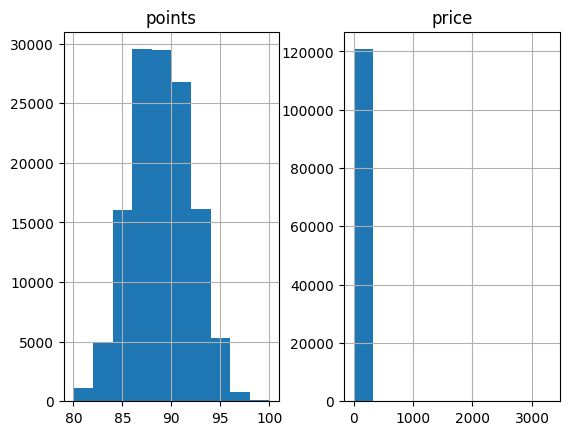

In [16]:
# построим распеределение всех возможных признаков быстрой просто визуализацией
hist = wine_data.hist()
hist

Ответ: points, price

### Задание 5.3

Проанализируйте датасет на наличие дублирующихся винных обзоров. Если дублирующиеся записи есть, удалите их. 
В поле ниже введите, сколько дублирующихся записей вам удалось обнаружить. 


In [ ]:
mask = df.duplicated(subset=df.columns) # маска для фильтрации
data_duplicates = df[mask] # фильтруем наш датасет
print(f'Число найденных дубликатов: {data_duplicates.shape[0]}')
df = df.drop_duplicates()

In [ ]:
# Вариант - 1

dupl_columns = list(wine_data.columns)

mask = wine_data.duplicated(subset=dupl_columns)
#display (mask)
wine_duplicates = wine_data[mask]
#display (wine_duplicates)
print(f'Число найденных дубликатов: {wine_duplicates.shape[0]}')

In [3]:
# Вариант - 2

mask = wine_data.duplicated(subset=wine_data.columns)
#display (mask)
wine_duplicates = wine_data[mask]
#display (wine_duplicates)
print(f'Число найденных дубликатов: {wine_duplicates.shape[0]}')

Число найденных дубликатов: 9983


In [4]:
wine_dedupped = wine_data.drop_duplicates(subset=wine_data.columns)
print(f'Результирующее число записей: {wine_dedupped.shape[0]}')

Результирующее число записей: 119988


### Задание 5.4

Проверьте датасет на наличие пропусков в данных.
В каких из представленных признаках были обнаружены пропуски?


In [19]:
wine_dedupped.info() # смотрим краткую информацию о наборе данных и даем ответ

<class 'pandas.core.frame.DataFrame'>
Index: 119988 entries, 0 to 129970
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   country                119929 non-null  object 
 1   description            119988 non-null  object 
 2   designation            85443 non-null   object 
 3   points                 119988 non-null  int64  
 4   price                  111593 non-null  float64
 5   province               119929 non-null  object 
 6   region_1               100428 non-null  object 
 7   region_2               46769 non-null   object 
 8   taster_name            95071 non-null   object 
 9   taster_twitter_handle  90542 non-null   object 
 10  title                  119988 non-null  object 
 11  variety                119987 non-null  object 
 12  winery                 119988 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 12.8+ MB


### Задание 5.5

Обработайте пропущенные значения в наборе данных любым известным вам способом, который вы изучили в  PYTHON-14. Очистка данных:

Воспользуйтесь правилами:
    
+ Если какой-то из признаков имеет более 30-40 % пропусков, лучше избавьтесь от него: его заполнение может привести к сильному искажению общего распределения, а удаление записей — к большой утрате данных.
+ Заполняйте данные с умом! Если перед вами количественный признак, то использование нецелого числа в качестве константы является как минимум нелогичным.
+ Вы можете оставить пропуски как есть, просто заменив их на какой-то специальный символ. Например, для числовых неотрицательных признаков можно использовать число -1, а для категориальных — строку 'unknown'.


<Axes: >

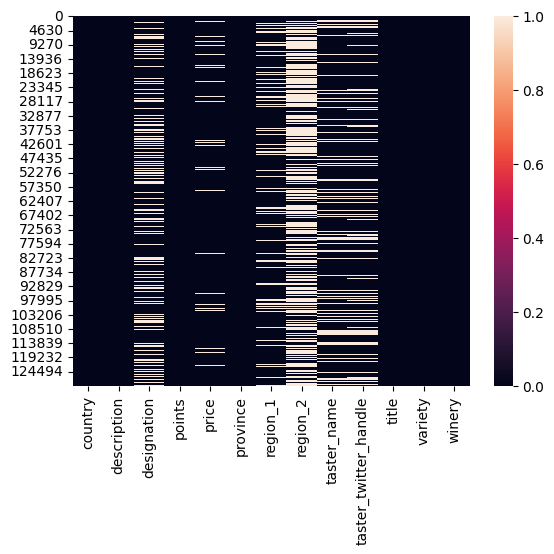

In [20]:
sns.heatmap(wine_dedupped.isnull()) # наглядная карта пропусков

In [ ]:
df = df.drop(['region_2'], axis=1) # имеет порядка 60% пропусков, лучше избавиться от такого признака

In [ ]:
sns.heatmap(df.isnull()) # смотрим, какие признаки остались

In [ ]:
df.head()

In [ ]:
df.describe(include='all')

In [ ]:
# обрабатываем пропуски в категориальных признаках самым простым вариантом, замена на unknown

df['designation'] = df['designation'].fillna('unknown')
df['region_1'] = df['region_1'].fillna('unknown')
df['taster_name'] = df['taster_name'].fillna('unknown')
df['taster_twitter_handle'] = df['taster_twitter_handle'].fillna('unknown')

# признаки с маленьким количеством пропусков заменим на самые частовречающиеся значения
df['country'] = df['country'].fillna('US')
df['price'] = df['price'].fillna(df['price'].mean())
df['province'] = df['province'].fillna('California')
df['variety'] = df['variety'].fillna('Pinot Noir')

In [ ]:
df.info()

In [ ]:
# в числовом признаке выберем метод замены средним значением
df['price'] = df['price'].fillna(df['price'].mean())

In [ ]:
sns.heatmap(df.isnull()) # убеждаемся, что датасет без пропусков

In [ ]:
df = df.to_csv('wine_cleared.csv', index=False) # сохраняем очищенный датасет для дальнейшей работы

In [21]:
# Вариант - 1


cols_null_percent = wine_dedupped.isnull().mean() * 100
#display (cols_null_percent)
cols_with_null = cols_null_percent[cols_null_percent>0].sort_values(ascending=False)
display(cols_with_null)

region_2                 61.021936
designation              28.790379
taster_twitter_handle    24.540787
taster_name              20.766243
region_1                 16.301630
price                     6.996533
country                   0.049172
province                  0.049172
variety                   0.000833
dtype: float64

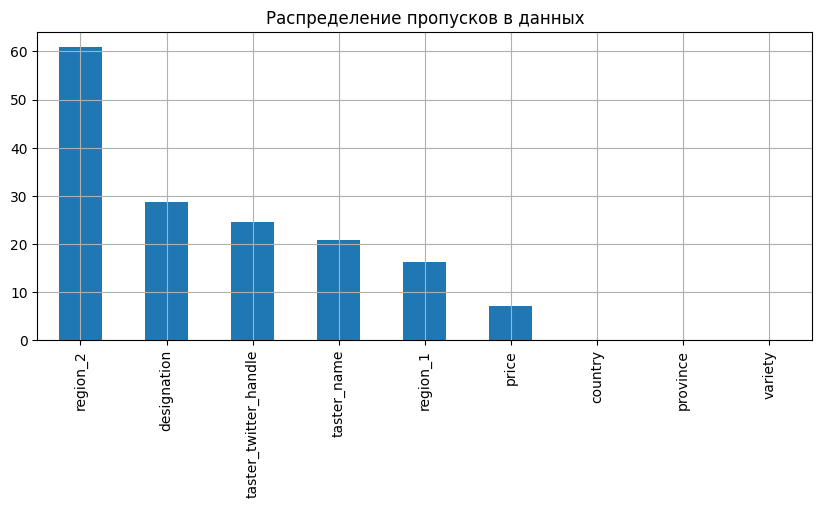

In [22]:
cols_with_null.plot(
    kind='bar',
    grid=True,
    figsize=(10, 4),
    title='Распределение пропусков в данных'
    );

In [28]:
cols = ['designation', 'taster_twitter_handle', 'taster_name','region_1']
for col in cols:
    wine_dedupped[col] = wine_dedupped[col].apply(lambda x: 'unknown' if x is np.nan else x)
#display (wine_dedupped[cols])

C:\Users\Пользователь\AppData\Local\Temp\ipykernel_2808\684834020.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wine_dedupped[col] = wine_dedupped[col].apply(lambda x: 'unknown' if x is np.nan else x)


In [ ]:
combine_data = wine_dedupped.copy()

n = combine_data.shape[0]
thresh = n*0.7
combine_data = combine_data.dropna(thresh=thresh, axis=1)

m = combine_data.shape[1]
combine_data = combine_data.dropna(thresh=m-2, axis=0)

values = {
    'price': combine_data['price'].median(),
    'country': combine_data['country'].mode()[0],
    'province': combine_data['province'].mode()[0],
    'variety': combine_data['variety'].mode()[0]
    }
combine_data = combine_data.fillna(values)

display(combine_data.isnull().mean())

In [8]:
# Вариант - 2

wine_dedupped.describe(include='all')

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
count,119929,119988,85443,119988.000000,111593.000000,119929,100428,46769,95071,90542,119988,119987,119988
unique,43,119955,37979,NaN,NaN,425,1229,17,19,15,118840,707,16757
top,US,This opens with subtle aromas of wild flower a...,Reserve,NaN,NaN,California,Napa Valley,Central Coast,Roger Voss,@vossroger,Gloria Ferrer NV Sonoma Brut Sparkling (Sonoma...,Pinot Noir,Wines & Winemakers
freq,50457,2,1871,NaN,NaN,33656,4174,10233,23560,23560,9,12278,211
mean,NaN,NaN,NaN,88.442236,35.620747,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,3.092915,42.103728,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,80.000000,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,86.000000,17.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,88.000000,25.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,91.000000,42.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
wine_dedupped = wine_dedupped.drop(['region_2'], axis=1) # имеет порядка 60% пропусков, лучше избавиться от такого признака


# обрабатываем пропуски в категориальных признаках самым простым вариантом, замена на unknown

wine_dedupped['designation'] = wine_dedupped['designation'].fillna('unknown')
wine_dedupped['region_1'] = wine_dedupped['region_1'].fillna('unknown')
wine_dedupped['taster_name'] = wine_dedupped['taster_name'].fillna('unknown')
wine_dedupped['taster_twitter_handle'] = wine_dedupped['taster_twitter_handle'].fillna('unknown')

# признаки с маленьким количеством пропусков заменим на самые частовречающиеся значения
wine_dedupped['country'] = wine_dedupped['country'].fillna('US')
wine_dedupped['province'] = wine_dedupped['province'].fillna('California')
wine_dedupped['variety'] = wine_dedupped['variety'].fillna('Pinot Noir')

wine_dedupped['price'] = wine_dedupped['price'].fillna(wine_dedupped['price'].mean()) # я бы заменил на median, т.к. она менее чувствительна к выбросам

In [6]:
display(wine_dedupped.isnull().mean())

country                  0.0
description              0.0
designation              0.0
points                   0.0
price                    0.0
province                 0.0
region_1                 0.0
taster_name              0.0
taster_twitter_handle    0.0
title                    0.0
variety                  0.0
winery                   0.0
dtype: float64

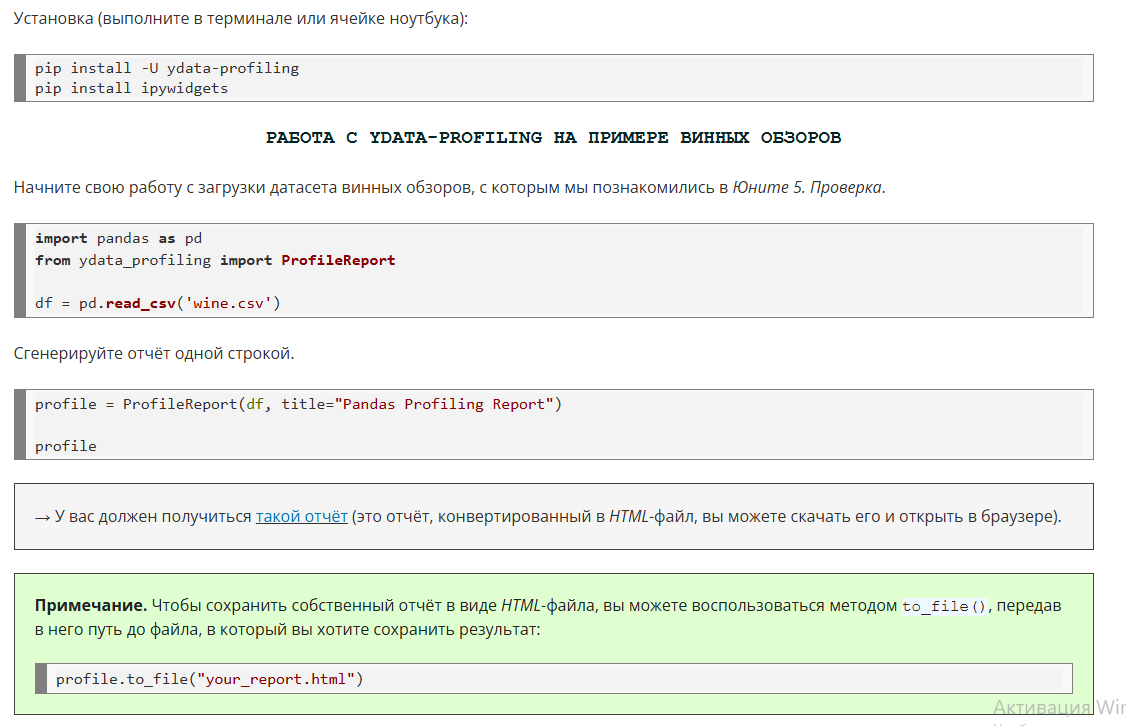

In [ ]:
# pip install ydata-profiling
# pip install ipywidgets

In [11]:
wine_dedupped.to_csv('data/wine_cleared.csv', index=False) # сохраняем очищенный датасет для дальнейшей работы

#wine_data = pd.read_csv('data/wine.csv', sep=',')
#countries_data.to_csv('data/countries.txt', index=False, sep=' ')

In [4]:
import pandas as pd
from ydata_profiling import ProfileReport

wine_dedupped = pd.read_csv('data/wine_cleared.csv', sep=',')

In [5]:
profile_wine_dedupped = ProfileReport(wine_dedupped, title="Pandas Profiling Report")

profile_wine_dedupped

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 13/13 [00:17<00:00,  1.38s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
profile_wine_dedupped.to_file('data/profile_wine_dedupped.html')

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

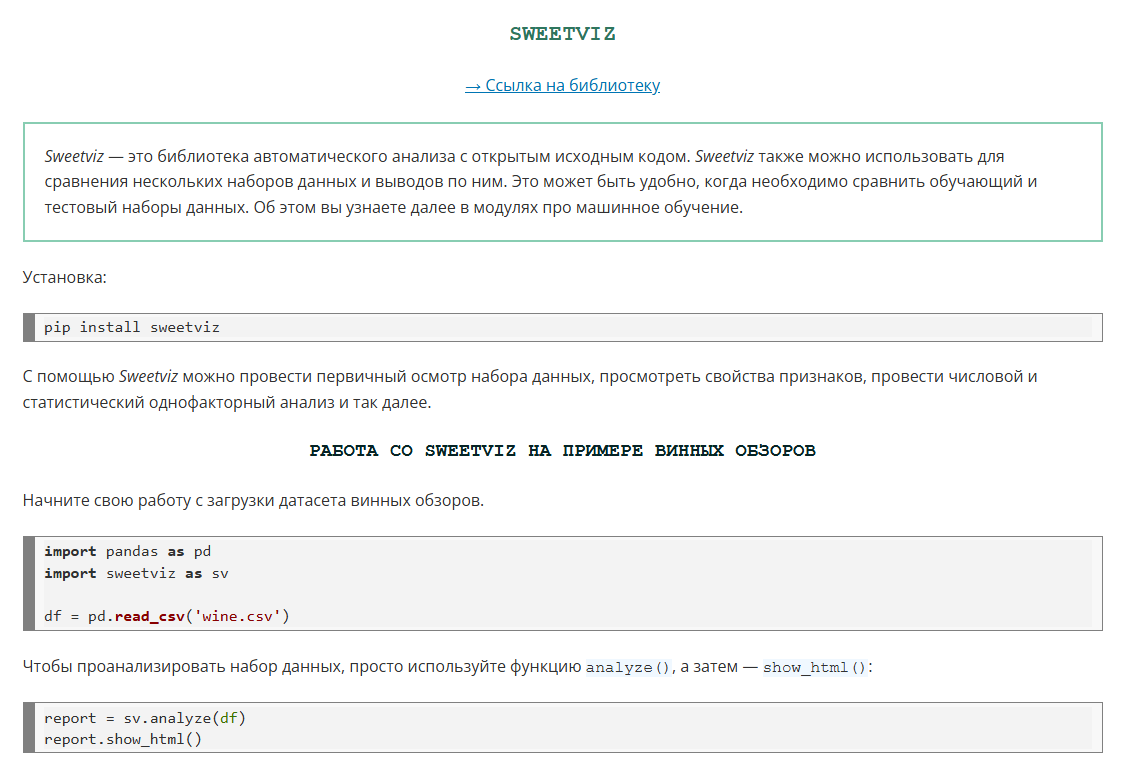

In [ ]:
# pip install sweetviz

In [2]:
import pandas as pd
import sweetviz as sv

wine_dedupped = pd.read_csv('data/wine_cleared.csv', sep=',')

c:\Users\Пользователь\AppData\Local\Programs\Python\Python39\lib\site-packages\sweetviz\graph.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [3]:
report = sv.analyze(wine_dedupped)
report.show_html()

                                             |          | [  0%]   00:00 -> (? left)

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


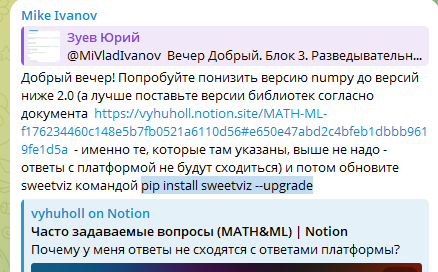

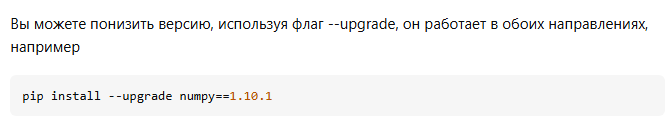

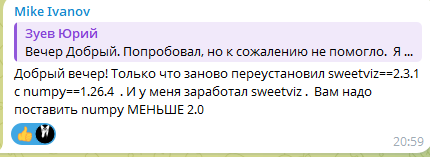

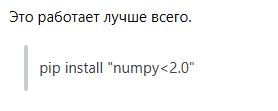

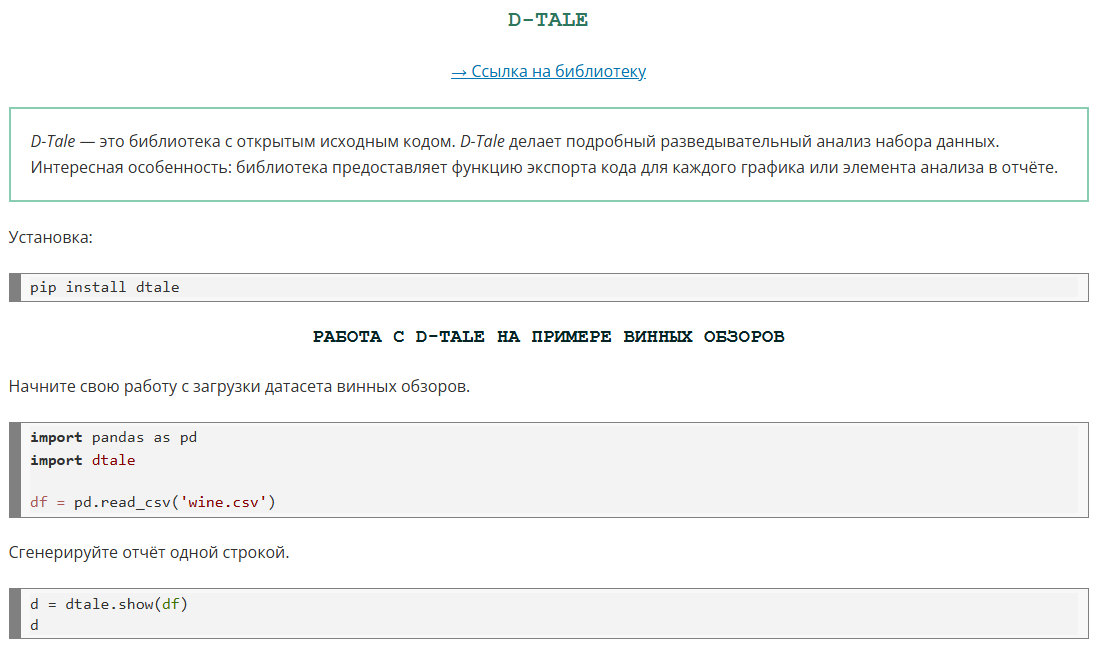

In [ ]:
# pip install dtale

In [4]:
# Начните свою работу с загрузки датасета винных обзоров.

import pandas as pd
import dtale

wine_dedupped = pd.read_csv('data/wine_cleared.csv', sep=',')

In [5]:
# Сгенерируйте отчёт одной строкой.

d = dtale.show(wine_dedupped)
d

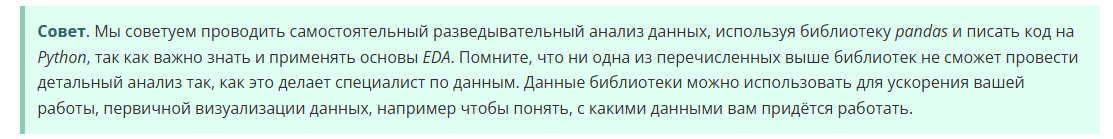

In [3]:
wine_dedupped = pd.read_csv('data/wine_cleared.csv', sep=',')
#display (wine_dedupped.info())
display (wine_dedupped['price'].min())

4.0

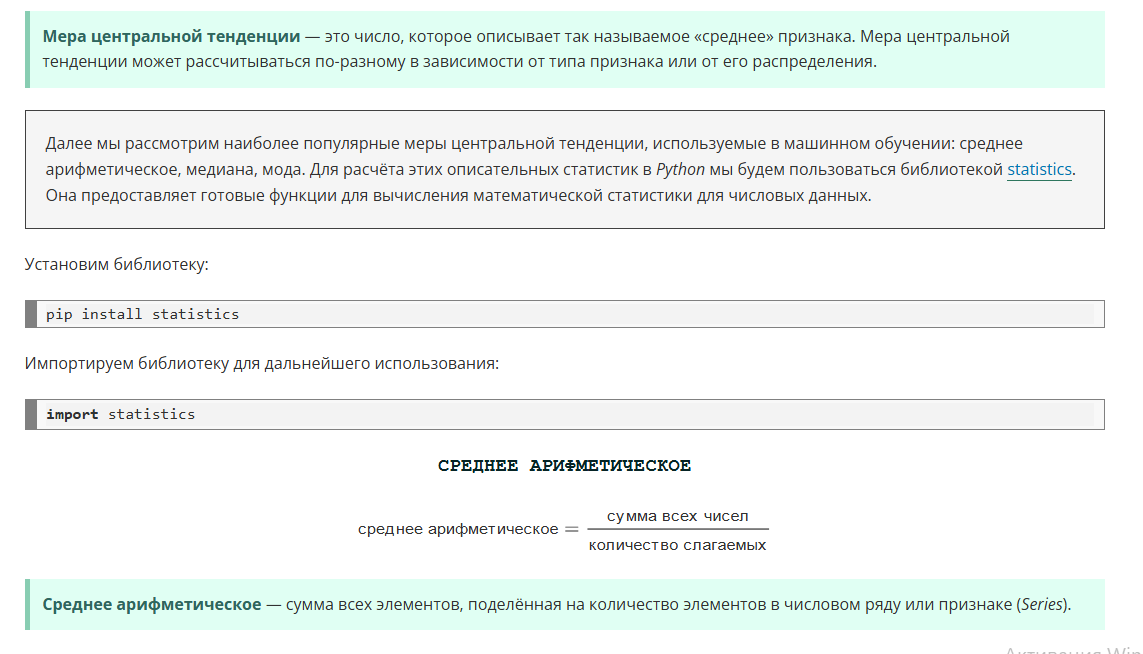

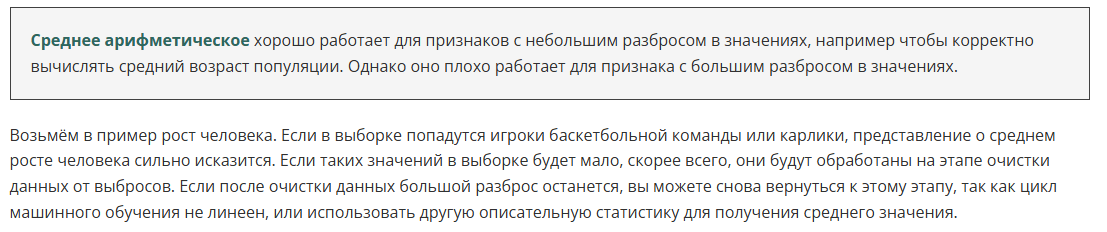

In [ ]:
# Установим библиотеку:

# pip install statistics

In [11]:
# Импортируем библиотеку для дальнейшего использования:

import statistics
a = wine_dedupped['price']
display (round(statistics.mean(a),2))

35.36

In [ ]:
# Вариант 1

display (round(wine_dedupped['price'].mean(),2))

35.36

In [16]:
# Вариант 2

mean = sum(wine_dedupped['price']) / len(wine_dedupped['price'])
display (round((mean),2))

35.36

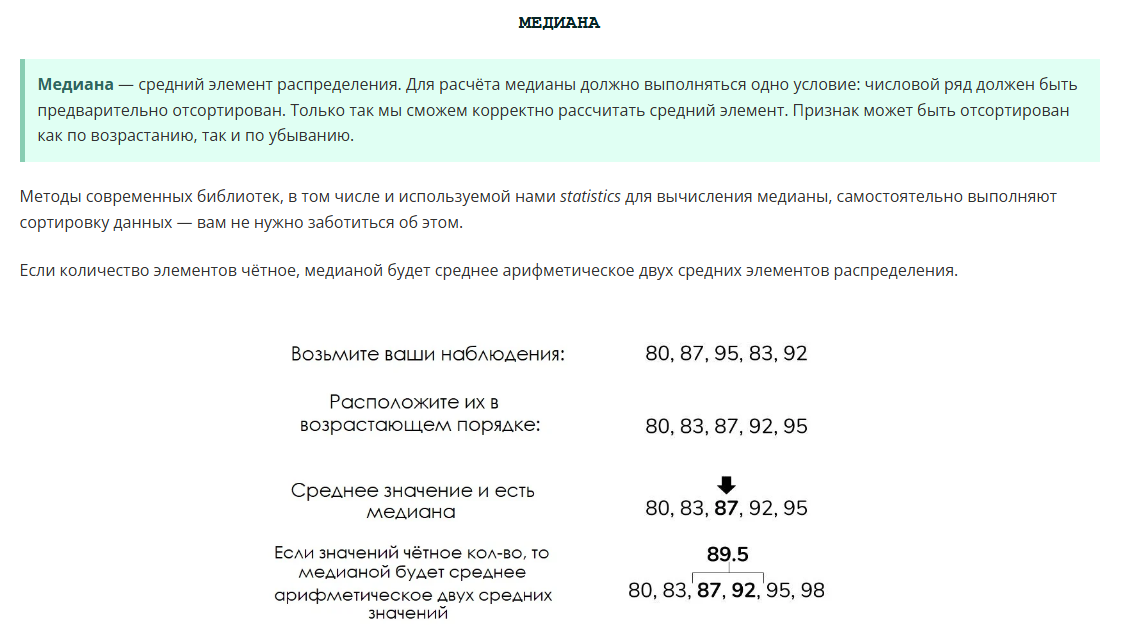

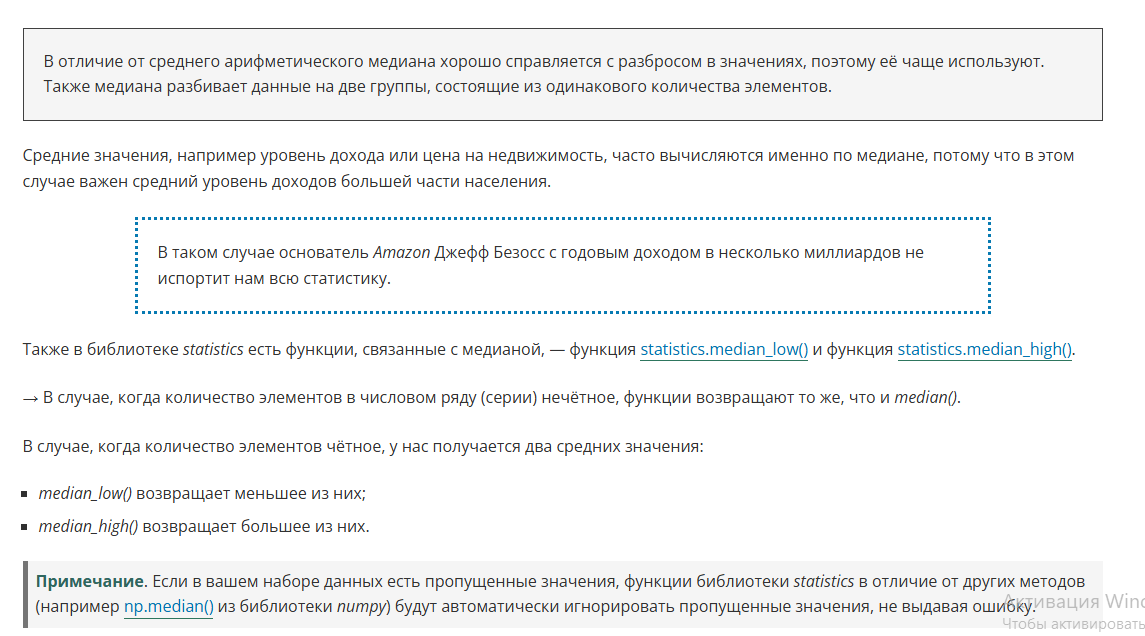

In [ ]:
import statistics
a = wine_dedupped['price']
display (round(statistics.median(a),2))

28.0

In [ ]:
# Вариант 1

display (round(wine_dedupped['price'].median(),2))

28.0

In [ ]:
# Вариант 2 - Код не по разобрал. 

count_price = len(wine_dedupped['price']) # количество записей цен
sorted_price = sorted(wine_dedupped['price']) # отсортированные цены

if count_price % 2: # при нечетном кол-ве элементов выбираем средний по индексу 
    median = sorted_price[round(0.5*(count_price-1))] # Пример - список от 1 до 11, получается (11-1)*0,5 = 5 - мендиана
else: # при четном кол-ве элементов выбираем 2 средних по индексу и считаем между ними среднее арифметическое
    index = round(0.5 * count_price) # Пример - список от 1 до 10, получается 10*0,5 = 5 (не забываем это № индекса), далее ((6-1)+(6))*0,5 = 5,5 - медиана
    median_ = 0.5 * (sorted_price[index-1] + sorted_price[index])
median

28.0